# Merge the meteo products and overview (2004-2025)

**notebook version**: `2` (21 Jul 2026)

## ℹ️ About this notebook

The capstone of the `30_PRODUCTS` stage. It reads the per-variable products written by notebooks
`01`-`08`, joins them onto one continuous 30MIN `TIMESTAMP_MID` index, writes a single merged file,
and draws a compact overview figure for each.

Nothing is computed or corrected here — the values are exactly what `01`-`08` exported. This
notebook only **collects** them and **looks** at them, so it must run after `01`-`08`.

**Outputs:**

- `99_METEO_MERGED_2004-2025.parquet` / `.csv` — every product value and its provenance flag in
  one wide table.
- One overview figure per series (displayed inline): daily time series, diurnal fingerprint,
  annual cycle, and the provenance flag composition per year (or the value distribution where a
  series carries no flag).

## 📇 Data sources

All inputs are the parquet products in the external data folder, written by earlier notebooks of
this stage. `SW_IN`/`TA`/`PPFD_IN` keep their `_gfXG` (gap-filled) columns; `RH` carries a
`_MISSING` provenance flag; `PA`/`LW_IN` are exported as measured with no flag; `VPD` is computed;
`PREC` contributes **two** value columns and **two** flags.

| notebook | value column | flag column | span |
|---|---|---|---|
| `01` `SW_IN` | `SW_IN_T1_47_1_gfXG` | `FLAG_SW_IN_T1_47_1_ISFILLED` | 2004-2025 |
| `02` `TA` | `TA_T1_47_1_gfXG` | `FLAG_TA_T1_47_1_ISFILLED` | 2004-2025 |
| `03` `PPFD_IN` | `PPFD_IN_T1_47_1_gfXG` | `FLAG_PPFD_IN_T1_47_1_ISFILLED` | 2004-2025 |
| `04` `RH` | `RH_T1_47_1` | `FLAG_RH_T1_47_1_MISSING` | 2004-2025 |
| `05` `PA` | `PA_T1_47_1` | — | 2005-2025 |
| `06` `LW_IN` | `LW_IN_T1_47_1` | — | 2005-2025 |
| `07` `VPD` | `VPD_T1_47_1` | `FLAG_VPD_T1_47_1_ISFILLED` | 2004-2025 |
| `08` `PREC` | `PREC_TOT_T1_47_1` | `FLAG_PREC_TOT_T1_47_1_ISFILLED` | 2004-2025 |
| `08` `PREC_HOM` | `PREC_TOT_T1_47_1_HOMOGENIZED` | `FLAG_PREC_TOT_T1_47_1_SOURCE` | 2004-2025 |

`PA` and `LW_IN` begin in September 2005, so they are `NaN` before then in the merged table.

::: {.callout-important title="Two things about PREC that the other variables do not have"}
**Two value columns.** `PREC_TOT_T1_47_1` is the measured series; `PREC_TOT_T1_47_1_HOMOGENIZED`
rescales its pre-2018 half onto the level of its post-2018 half, because the gauge's acquisition
chain changed in mid-2018 and the early era reads ~20% low (notebook `08` establishes this against
thirteen MeteoSwiss stations). **Use the homogenised column for anything crossing 2018 and the
measured column for everything else.** They are listed as two entries below so that each gets its
own overview figure.

**Both flags describe both columns.** The pairing in the table above is only about which flag is
more informative in that series' figure: `ISFILLED` (measured / filled from OED / still missing)
for the measured series, `SOURCE` (which acquisition era and screened record) for the homogenised
one, since the era is exactly what the homogenisation acts on. All four columns are in the merged
file and apply to both value columns.

**`PREC` still contains `NaN`** — 2,224 half-hours before Sep 2014 that have no sub-daily reference
to fill them from. Do not read them as dry.
:::

## ⚙️ Settings

In [1]:
from pathlib import Path

# Products live in the external (untracked) data folder, alongside where the merged file is written.
PRODDIR = Path(r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
               r"\workflow\10_METEO\30_PRODUCTS")

OUTNAME = "99_METEO_MERGED_2004-2025"

# (file stem, value column, flag column or None, short name, units, aggregation)
#
# `aggregation` is how the variable must be summarised over time in the overview figures: state
# variables average, precipitation SUMS. A daily "mean" of 30-min rainfall is about 0.05 mm and
# means nothing to anyone; a daily total is the number people know.
#
# PREC appears twice, from the same file: the measured series and the homogenised one. See the
# data-sources note above for why both ship and which flag is shown with which.
PRODUCTS = [
    ("01_METEO_SW_IN_GAPFILLED_2004-2025",   "SW_IN_T1_47_1_gfXG",   "FLAG_SW_IN_T1_47_1_ISFILLED",   "SW_IN",    "W m$^{-2}$",              "mean"),
    ("02_METEO_TA_GAPFILLED_2004-2025",      "TA_T1_47_1_gfXG",      "FLAG_TA_T1_47_1_ISFILLED",      "TA",       "°C",                      "mean"),
    ("03_METEO_PPFD_IN_GAPFILLED_2004-2025", "PPFD_IN_T1_47_1_gfXG", "FLAG_PPFD_IN_T1_47_1_ISFILLED", "PPFD_IN",  "µmol m$^{-2}$ s$^{-1}$",  "mean"),
    ("04_METEO_RH_CORRECTED_2004-2025",      "RH_T1_47_1",           "FLAG_RH_T1_47_1_MISSING",       "RH",       "%",                       "mean"),
    ("05_METEO_PA_2005-2025",                "PA_T1_47_1",           None,                            "PA",       "kPa",                     "mean"),
    ("06_METEO_LW_IN_2005-2025",             "LW_IN_T1_47_1",        None,                            "LW_IN",    "W m$^{-2}$",              "mean"),
    ("07_METEO_VPD_2004-2025",               "VPD_T1_47_1",          "FLAG_VPD_T1_47_1_ISFILLED",     "VPD",      "kPa",                     "mean"),
    ("08_METEO_PREC_GAPFILLED_2004-2025",    "PREC_TOT_T1_47_1",             "FLAG_PREC_TOT_T1_47_1_ISFILLED", "PREC",     "mm (30min)$^{-1}$", "sum"),
    ("08_METEO_PREC_GAPFILLED_2004-2025",    "PREC_TOT_T1_47_1_HOMOGENIZED", "FLAG_PREC_TOT_T1_47_1_SOURCE",   "PREC_HOM", "mm (30min)$^{-1}$", "sum"),
]

# Series that are allowed to contain NaN, with the reason. Everything else must be complete.
MAY_HAVE_GAPS = {
    "PA": "sensor starts 2005-09",
    "LW_IN": "sensor starts 2005-09",
    "PREC": "no sub-daily reference before Sep 2014",
    "PREC_HOM": "no sub-daily reference before Sep 2014",
}

# Short labels for the provenance-flag legend. Codes differ per variable (see the source notebooks);
# unlisted codes fall back to "flag N".
FLAG_LABELS = {
    "SW_IN":   {0: "measured", 1: "model", 2: "fallback", 3: "night 0", 4: "interp"},
    "TA":      {0: "measured", 1: "model", 2: "fallback", 4: "interp"},
    "PPFD_IN": {0: "measured", 1: "model", 2: "fallback", 3: "night 0", 4: "interp"},
    "RH":      {0: "measured", 1: "never", 2: "removed", 3: "NABEL", 4: "Lägern"},
    "VPD":     {0: "measured", 5: "TA filled", 6: "RH NABEL", 7: "RH Lägern"},
    "PREC":    {0: "measured", 1: "OED fill", 2: "no reference"},
    "PREC_HOM": {0: "not measured", 1: "EMPA era", 2: "transition", 3: "ETH/NABEL rec",
                 4: "ETH/mst", 5: "ETH/diive"},
}
EXPORT_FORMATS = ("parquet", "csv")

### Imports

In [2]:
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

import diive as dv

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 1000)
print(f"Last run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"pandas v{pd.__version__}, diive v{dv.__version__ if hasattr(dv, '__version__') else '?'}")

Last run: 2026-07-21 16:57:33
pandas v3.0.3, diive v0.91.0


## ⬇️ Load and merge

In [3]:
frames, seen = [], set()
for _stem, _vcol, _fcol, _short, _units, _agg in PRODUCTS:
    # PREC contributes two entries from one file, so a column must only be taken once.
    _cols = [c for c in ([_vcol] + ([_fcol] if _fcol else [])) if c not in seen]
    seen.update(_cols)
    _df = pd.read_parquet(PRODDIR / f"{_stem}.parquet")[_cols]
    print(f"{_short:<9} {_stem:<40} {len(_df):>7,} rows  {_df.index[0]} -> {_df.index[-1]}"
          f"  [{', '.join(_cols)}]")
    frames.append(_df)

merged = pd.concat(frames, axis=1)
merged.index.name = frames[0].index.name
print(f"\nMerged: {len(merged):,} rows x {merged.shape[1]} columns, "
      f"{merged.index[0]} -> {merged.index[-1]} ({merged.index.name})")
merged.head()

SW_IN     01_METEO_SW_IN_GAPFILLED_2004-2025       385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00  [SW_IN_T1_47_1_gfXG, FLAG_SW_IN_T1_47_1_ISFILLED]
TA        02_METEO_TA_GAPFILLED_2004-2025          385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00  [TA_T1_47_1_gfXG, FLAG_TA_T1_47_1_ISFILLED]
PPFD_IN   03_METEO_PPFD_IN_GAPFILLED_2004-2025     385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00  [PPFD_IN_T1_47_1_gfXG, FLAG_PPFD_IN_T1_47_1_ISFILLED]
RH        04_METEO_RH_CORRECTED_2004-2025          385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00  [RH_T1_47_1, FLAG_RH_T1_47_1_MISSING]
PA        05_METEO_PA_2005-2025                    356,448 rows  2005-09-02 00:15:00 -> 2025-12-31 23:45:00  [PA_T1_47_1]
LW_IN     06_METEO_LW_IN_2005-2025                 355,872 rows  2005-09-14 00:15:00 -> 2025-12-31 23:45:00  [LW_IN_T1_47_1]
VPD       07_METEO_VPD_2004-2025                   385,728 rows  2004-01-01 00:15:00 -> 2025-12-31 23:45:00  [VPD_T1_47_1, FLAG_VPD


Merged: 385,728 rows x 16 columns, 2004-01-01 00:15:00 -> 2025-12-31 23:45:00 (TIMESTAMP_MIDDLE)


,SW_IN_T1_47_1_gfXG,FLAG_SW_IN_T1_47_1_ISFILLED,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED,PPFD_IN_T1_47_1_gfXG,FLAG_PPFD_IN_T1_47_1_ISFILLED,RH_T1_47_1,FLAG_RH_T1_47_1_MISSING,PA_T1_47_1,LW_IN_T1_47_1,VPD_T1_47_1,FLAG_VPD_T1_47_1_ISFILLED,PREC_TOT_T1_47_1,FLAG_PREC_TOT_T1_47_1_ISFILLED,PREC_TOT_T1_47_1_HOMOGENIZED,FLAG_PREC_TOT_T1_47_1_SOURCE
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,
2004-01-01 00:15:00,0.0,3,6.938439,2,0.0,3,97.718962,3,NaN,NaN,0.022776,6,0.0,0,0.0,1
2004-01-01 00:45:00,0.0,3,6.938439,2,0.0,3,96.918962,3,NaN,NaN,0.030765,6,0.0,0,0.0,1
2004-01-01 01:15:00,0.0,3,8.341139,2,0.0,3,93.552296,3,NaN,NaN,0.070865,6,0.0,0,0.0,1
2004-01-01 01:45:00,0.0,3,8.341139,2,0.0,3,92.652296,3,NaN,NaN,0.080756,6,0.0,0,0.0,1
2004-01-01 02:15:00,0.0,3,8.205807,2,0.0,3,93.985629,3,NaN,NaN,0.065496,6,0.0,0,0.0,1


### Sanity checks

The index must be the continuous 30MIN axis all seven products share, and every expected column
must be present. Missing values are allowed only for `PA`/`LW_IN` before September 2005.

In [4]:
assert merged.index.is_monotonic_increasing and not merged.index.has_duplicates
_diffs = merged.index.to_series().diff().dropna().unique()
assert len(_diffs) == 1 and _diffs[0] == pd.Timedelta('30min'), f"irregular index: {_diffs}"

_expected, _seen = [], set()
for _s, _v, _f, _n, _u, _a in PRODUCTS:
    for _c in [_v] + ([_f] if _f else []):
        if _c not in _seen:
            _expected.append(_c)
            _seen.add(_c)
assert list(merged.columns) == _expected, "unexpected column set"
assert len(merged.columns) == len(set(merged.columns)), "a column was merged in twice"

# Complete products must have no NaN; the ones in MAY_HAVE_GAPS carry a documented reason.
for _stem, _vcol, _fcol, _short, _units, _agg in PRODUCTS:
    _n = int(merged[_vcol].isna().sum())
    if _n == 0:
        _tag = "OK"
    elif _short in MAY_HAVE_GAPS:
        _tag = f"OK, expected ({MAY_HAVE_GAPS[_short]})"
    else:
        _tag = "!! unexpected NaN"
    print(f"  {_short:<9} {_vcol:<30} NaN={_n:>6,}  {_tag}")
    assert _n == 0 or _short in MAY_HAVE_GAPS, f"{_short} has undocumented gaps"
print("\nIndex and columns validated.")

  SW_IN     SW_IN_T1_47_1_gfXG             NaN=     0  OK
  TA        TA_T1_47_1_gfXG                NaN=     0  OK
  PPFD_IN   PPFD_IN_T1_47_1_gfXG           NaN=     0  OK
  RH        RH_T1_47_1                     NaN=     0  OK
  PA        PA_T1_47_1                     NaN=33,290  OK, expected (sensor starts 2005-09)
  LW_IN     LW_IN_T1_47_1                  NaN=34,759  OK, expected (sensor starts 2005-09)
  VPD       VPD_T1_47_1                    NaN=     0  OK
  PREC      PREC_TOT_T1_47_1               NaN= 2,224  OK, expected (no sub-daily reference before Sep 2014)
  PREC_HOM  PREC_TOT_T1_47_1_HOMOGENIZED   NaN= 2,224  OK, expected (no sub-daily reference before Sep 2014)

Index and columns validated.


### Coverage per variable
When each product starts, and how its records break down by provenance flag.

In [5]:
rows = []
for _stem, _vcol, _fcol, _short, _units, _agg in PRODUCTS:
    _s = merged[_vcol]
    _first = _s.first_valid_index()
    _row = {"variable": _short, "units": _units.replace('$', '').replace('^', ''),
            "agg": _agg,
            "start": _first.date() if _first is not None else None,
            "present_%": round(_s.notna().mean() * 100, 2)}
    if _fcol:
        _fc = merged[_fcol].value_counts(normalize=True).mul(100).round(1)
        _row["flags (% by code)"] = {int(k): v for k, v in _fc.sort_index().items()}
    else:
        _row["flags (% by code)"] = "no flag"
    rows.append(_row)
pd.DataFrame(rows).set_index("variable")

,units,agg,start,present_%,flags (% by code)
variable,,,,,
SW_IN,W m{-2},mean,2004-01-01,100.00,"{0: 91.2, 1: 4.5, 2: 0.2, 3: 4.1}"
TA,°C,mean,2004-01-01,100.00,"{0: 95.7, 1: 3.9, 2: 0.4, 4: 0.0}"
PPFD_IN,µmol m{-2} s{-1},mean,2004-01-01,100.00,"{0: 95.7, 1: 2.2, 2: 0.2, 3: 2.0, 4: 0.0}"
RH,%,mean,2004-01-01,100.00,"{0: 95.7, 3: 4.1, 4: 0.2}"
PA,kPa,mean,2005-09-02,91.37,no flag
LW_IN,W m{-2},mean,2005-09-14,90.99,no flag
VPD,kPa,mean,2004-01-01,100.00,"{0: 95.7, 5: 0.0, 6: 4.1, 7: 0.2}"
PREC,mm (30min){-1},sum,2004-01-01,99.42,"{0: 99.2, 1: 0.2, 2: 0.6}"
PREC_HOM,mm (30min){-1},sum,2004-01-01,99.42,"{0: 0.8, 1: 64.9, 2: 0.9, 3: 1.8, 4: 4.4, 5: 2..."


## 💾 Export the merged file

In [6]:
outpath = PRODDIR / f"{OUTNAME}.parquet"
written = []
for _fmt in EXPORT_FORMATS:
    _p = PRODDIR / f"{OUTNAME}.{_fmt}"
    if _fmt == "parquet":
        merged.to_parquet(_p)
    else:
        merged.to_csv(_p, index=True, na_rep="")  # NaN stays empty so a gap can't read as a value
    written.append(_p)
    print(f"Wrote {_p.name:<40} ({_p.stat().st_size / 1024:>8.0f} KB)")

# Read the parquet back and check it matches, rather than trusting the in-memory frame.
_back = pd.read_parquet(PRODDIR / f"{OUTNAME}.parquet")
assert _back.shape == merged.shape and list(_back.columns) == list(merged.columns)
assert _back.index.equals(merged.index)
print("\nRead back: matches the merged frame.")

Wrote 99_METEO_MERGED_2004-2025.parquet        (   18729 KB)


Wrote 99_METEO_MERGED_2004-2025.csv            (   57305 KB)

Read back: matches the merged frame.


## 📊 Overview figures

One figure per series, four views:

- **Daily mean**, or **daily total** for precipitation — over the whole record, with a 30-day
  rolling mean.
- **Fingerprint** — the diive `HeatmapDateTime`, date on the vertical axis against time of day, so
  the diurnal cycle and any gaps or shifts are visible at a glance.
- **Annual cycle** — monthly mean ± 1 SD, or the mean monthly total ± SD for precipitation.
- **Provenance flag, % per year** — the stacked composition of the flag codes, or, where a series
  carries no flag (`PA`, `LW_IN`), the distribution of its 30-min values.

The two `PREC` figures are worth comparing: the acquisition break of mid-2018 is plain in the
measured series' daily totals and annual cycle, and gone from the homogenised one.

In [7]:
def overview_figure(series, flag, short, units, flag_labels, agg='mean'):
    """Draw a four-view overview for one variable and return the figure.

    *agg* is 'mean' for state variables and 'sum' for fluxes of mass such as precipitation, where
    a daily or monthly MEAN of 30-min values is not a quantity anyone uses. It changes the two
    time-aggregating panels only; the fingerprint always shows the 30-min values themselves.
    """
    if agg not in ('mean', 'sum'):
        raise ValueError(f"agg must be 'mean' or 'sum', got {agg!r}")
    _is_sum = agg == 'sum'

    fig = plt.figure(figsize=(17, 8.5), dpi=90, layout='constrained')
    gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[1.4, 1.4, 1.0])
    fig.suptitle(f"{short}   [{units}]", fontsize=18, fontweight='bold')

    # Daily mean (or total) + 30-day rolling mean
    ax = fig.add_subplot(gs[0, 0:2])
    _d = series.resample('D').sum(min_count=1) if _is_sum else series.resample('D').mean()
    _dunits = 'mm d$^{-1}$' if _is_sum else units
    ax.plot(_d.index, _d.values, lw=0.4, color='#4C72B0', alpha=.55)
    ax.plot(_d.index, _d.rolling(30, center=True).mean().values, lw=1.3, color='#C44E52',
            label='30-day mean')
    ax.set_title('Daily total' if _is_sum else 'Daily mean', fontsize=11)
    ax.set_ylabel(_dunits)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=.3)

    # Diurnal fingerprint (diive HeatmapDateTime)
    ax = fig.add_subplot(gs[0:2, 2])
    dv.plotting.HeatmapDateTime(series=series).plot(
        ax=ax, cb_digits_after_comma=0 if not _is_sum else 1,
        format_style=dv.plotting.FormatStyle(title='Fingerprint', title_fontsize=11))

    # Annual cycle: monthly mean +/- SD, or the mean monthly total +/- SD across years
    ax = fig.add_subplot(gs[1, 0])
    if _is_sum:
        _monthly = series.resample('MS').sum(min_count=1)
        _g = _monthly.groupby(_monthly.index.month)
        _title, _ylab = 'Annual cycle (mean monthly total ± SD)', 'mm month$^{-1}$'
    else:
        _g = series.groupby(series.index.month)
        _title, _ylab = 'Annual cycle (monthly mean ± SD)', units
    _m, _sd = _g.mean(), _g.std()
    ax.plot(_m.index, _m.values, color='#C44E52', marker='o', ms=3)
    ax.fill_between(_m.index, (_m - _sd).values, (_m + _sd).values, color='#C44E52', alpha=.18)
    ax.set_title(_title, fontsize=11)
    ax.set_xlabel('month')
    ax.set_ylabel(_ylab)
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=.3)

    # Flag composition per year, or the value distribution where there is no flag
    ax = fig.add_subplot(gs[1, 1])
    if flag is not None:
        comp = flag.groupby([flag.index.year, flag]).size().unstack(fill_value=0)
        comp = comp.div(comp.sum(axis=1), axis=0) * 100
        cmap = plt.get_cmap('viridis', max(len(comp.columns), 2))
        bottom = np.zeros(len(comp))
        for j, code in enumerate(comp.columns):
            _lab = flag_labels.get(int(code), f'flag {int(code)}')
            ax.bar(comp.index, comp[code].values, bottom=bottom, width=.9,
                   color=cmap(j), label=f'{int(code)} {_lab}')
            bottom += comp[code].values
        ax.set_title('Provenance flag, % per year', fontsize=11)
        ax.set_ylabel('%')
        ax.set_ylim(0, 100)
        # The stacked bars fill the axes from 0 to 100%, so an in-axes legend always
        # covers data. Put it below the panel; constrained layout reserves the space.
        ax.legend(fontsize=8, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.13),
                  frameon=False, handlelength=1.3, handletextpad=.5, columnspacing=1.4)
    else:
        ax.hist(series.dropna().values, bins=60, color='#55A868', alpha=.85)
        ax.set_title('Distribution of 30-min values (no flag)', fontsize=11)
        ax.set_xlabel(units)
        ax.set_ylabel('count')
    ax.grid(alpha=.3)
    return fig

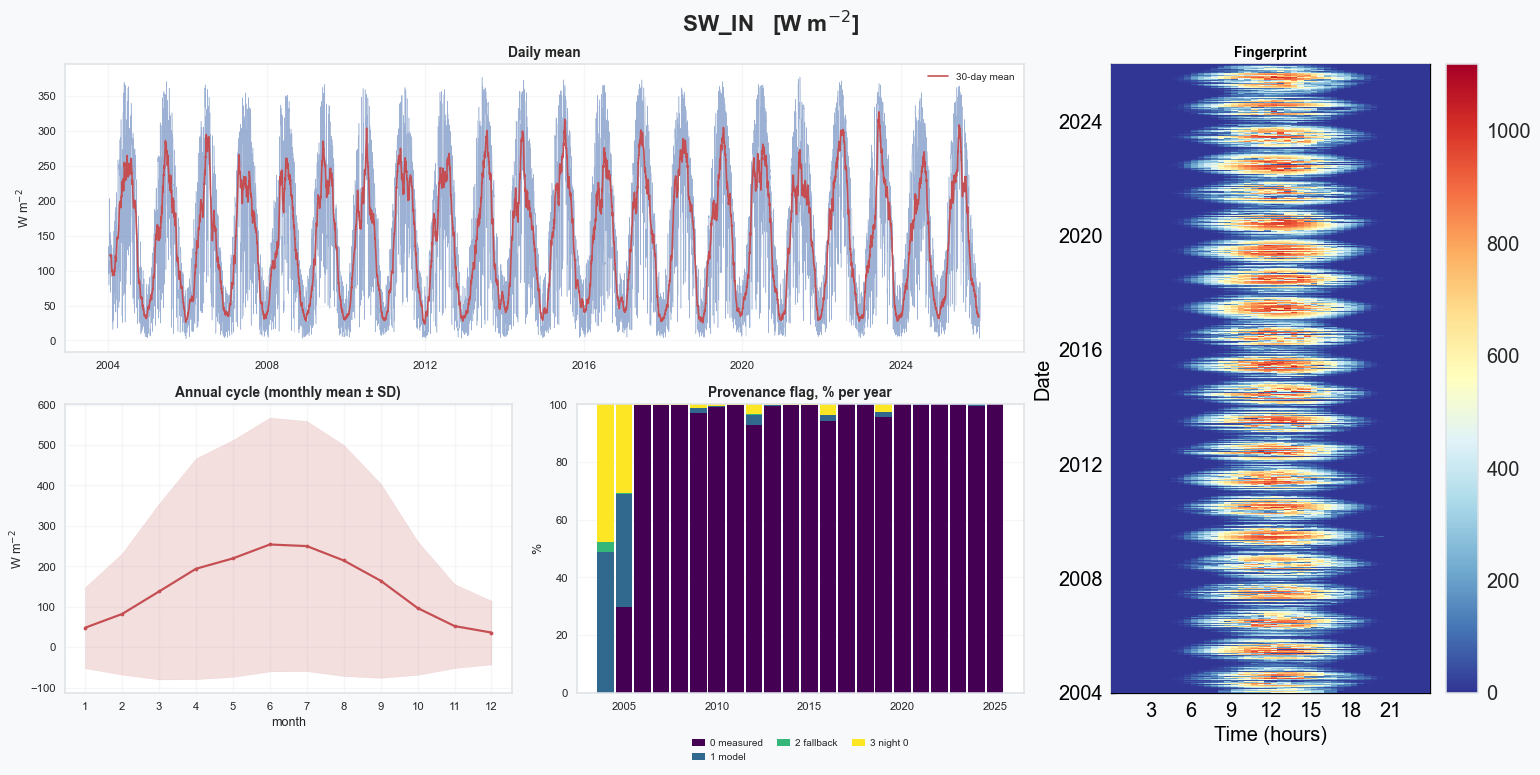

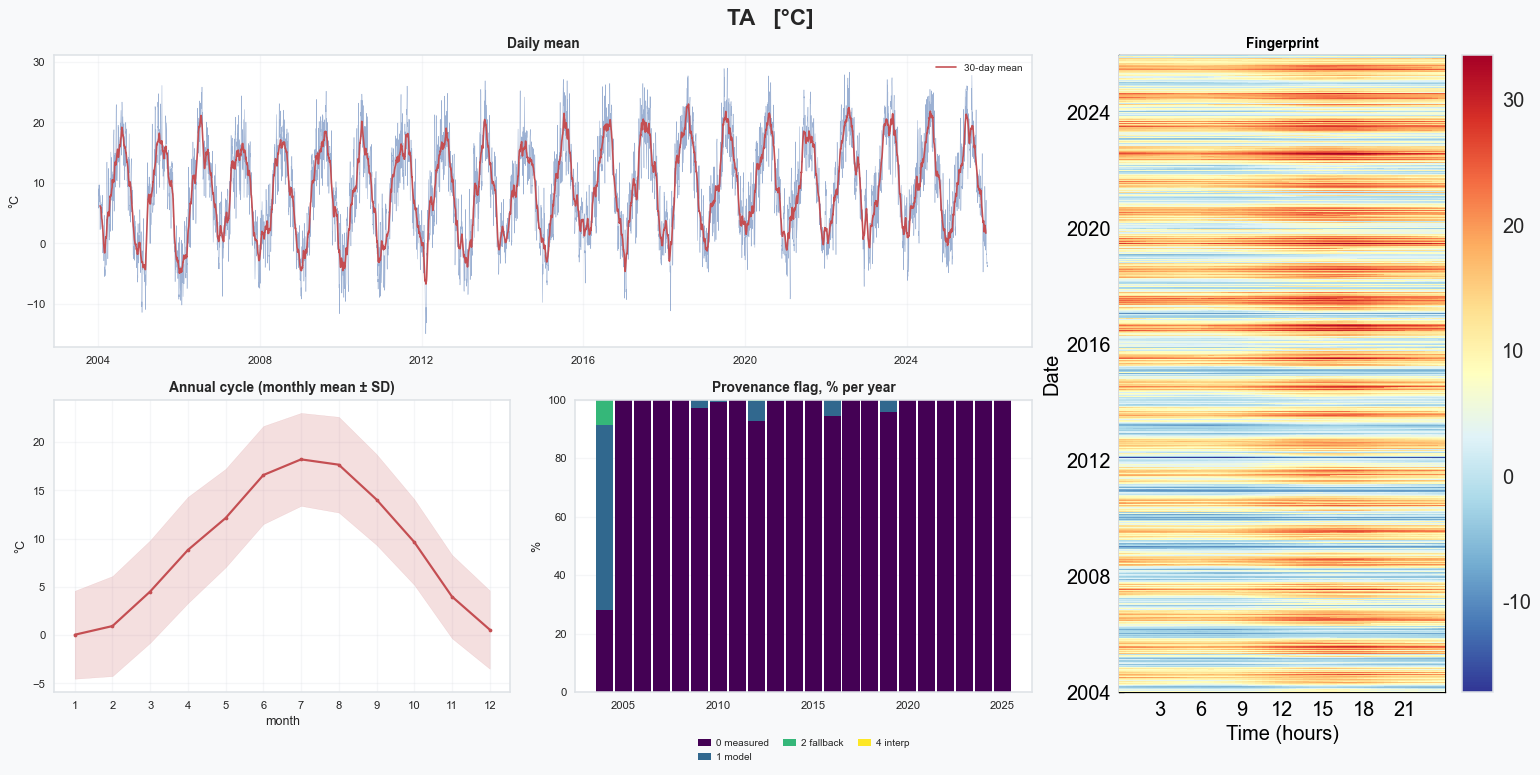

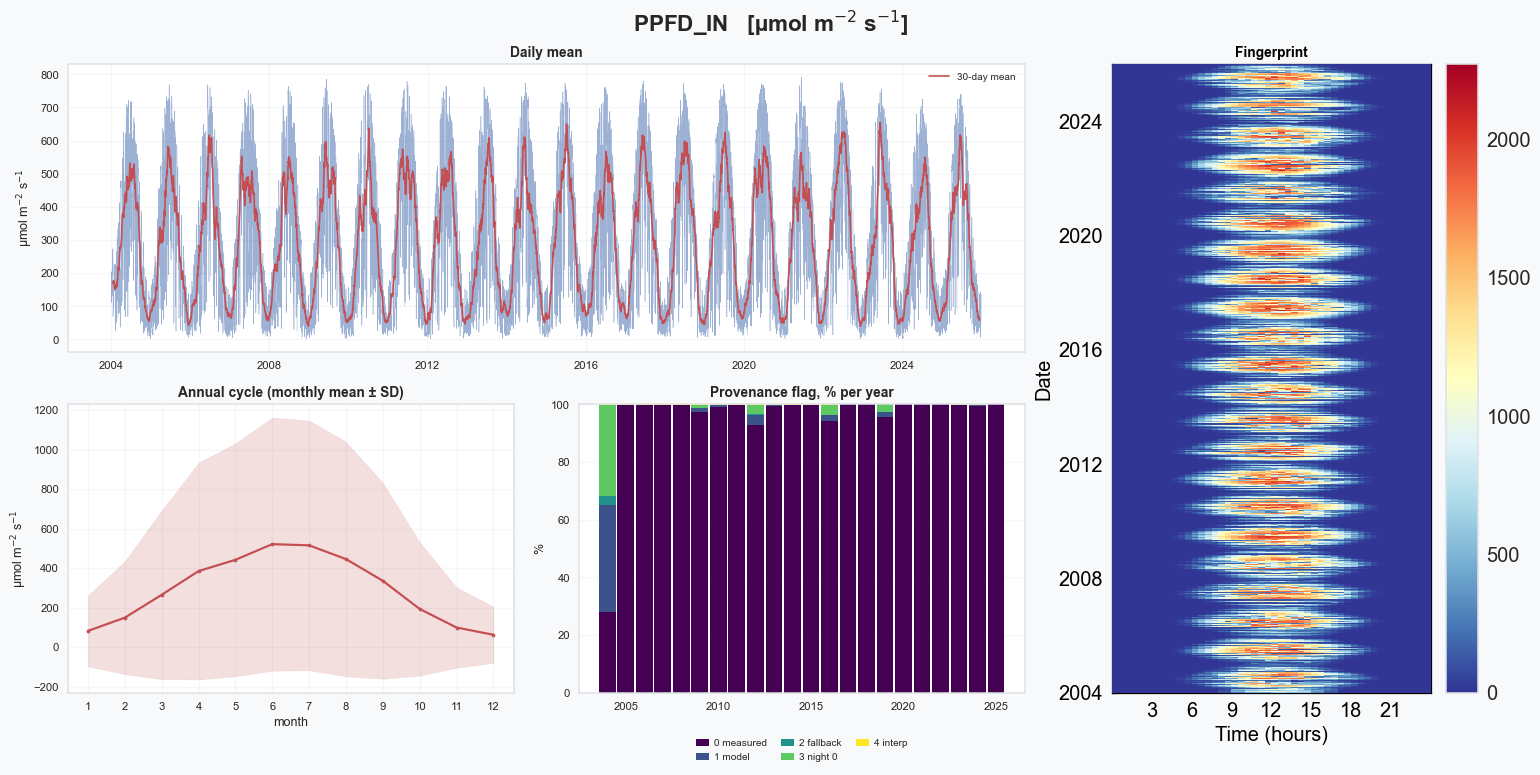

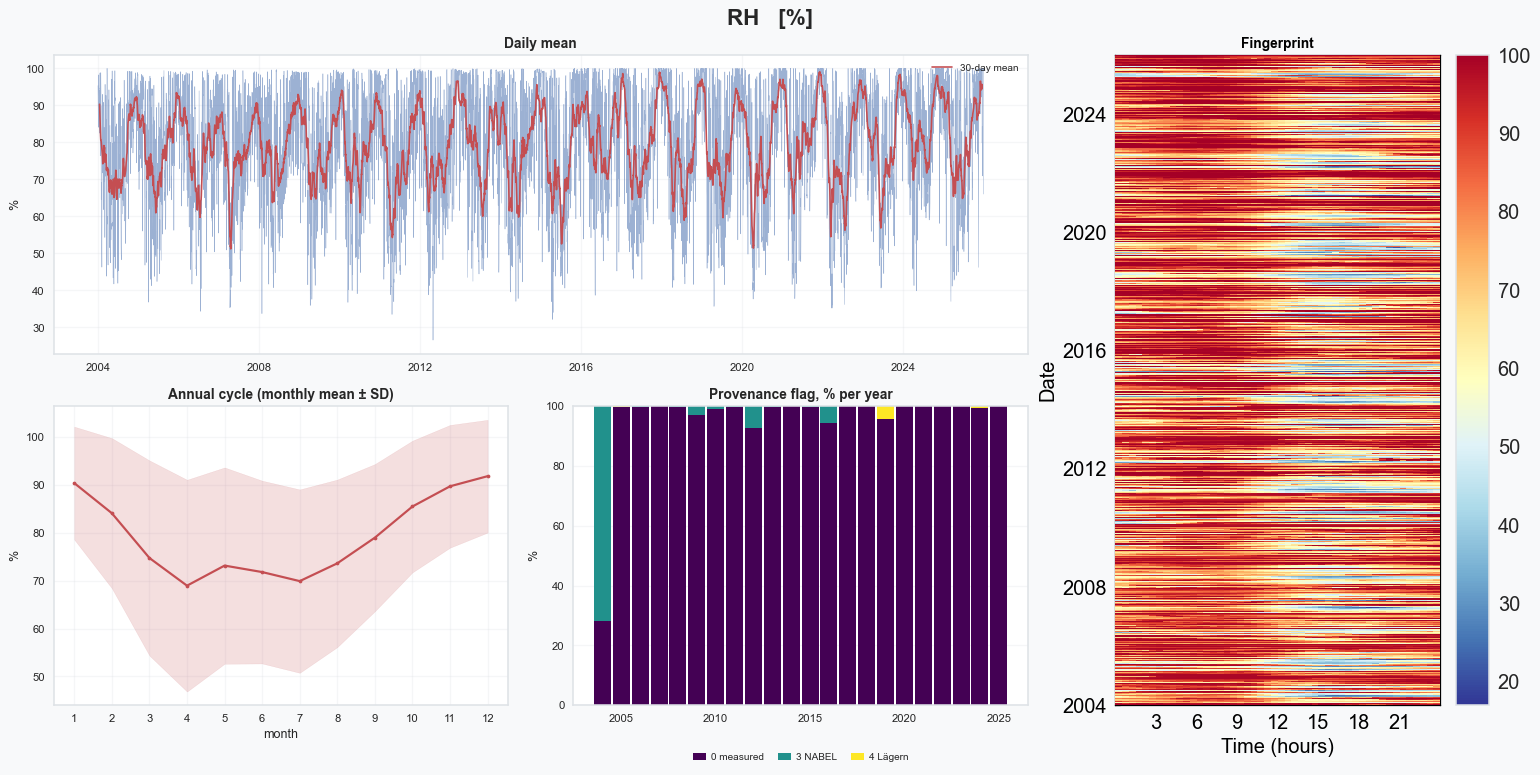

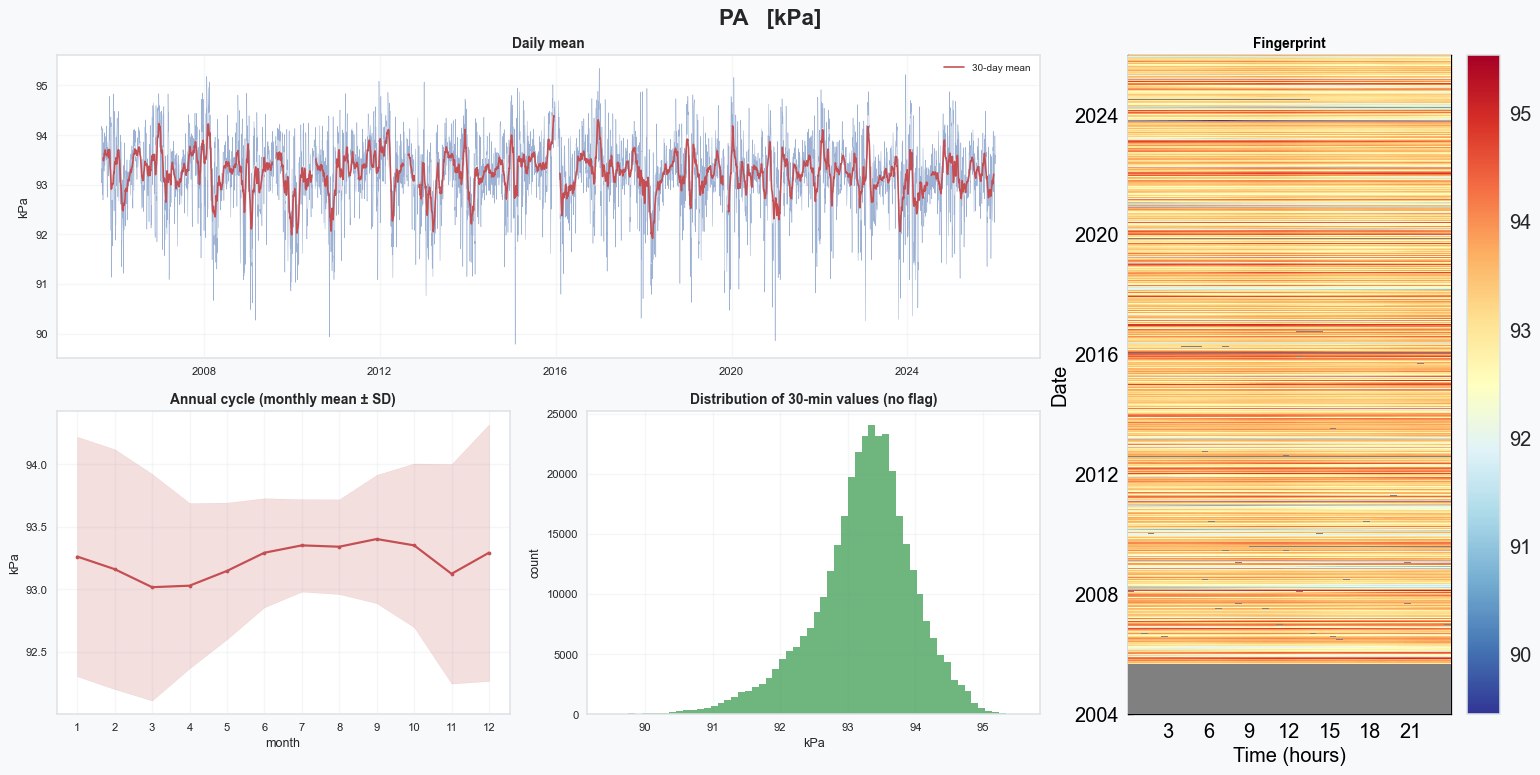

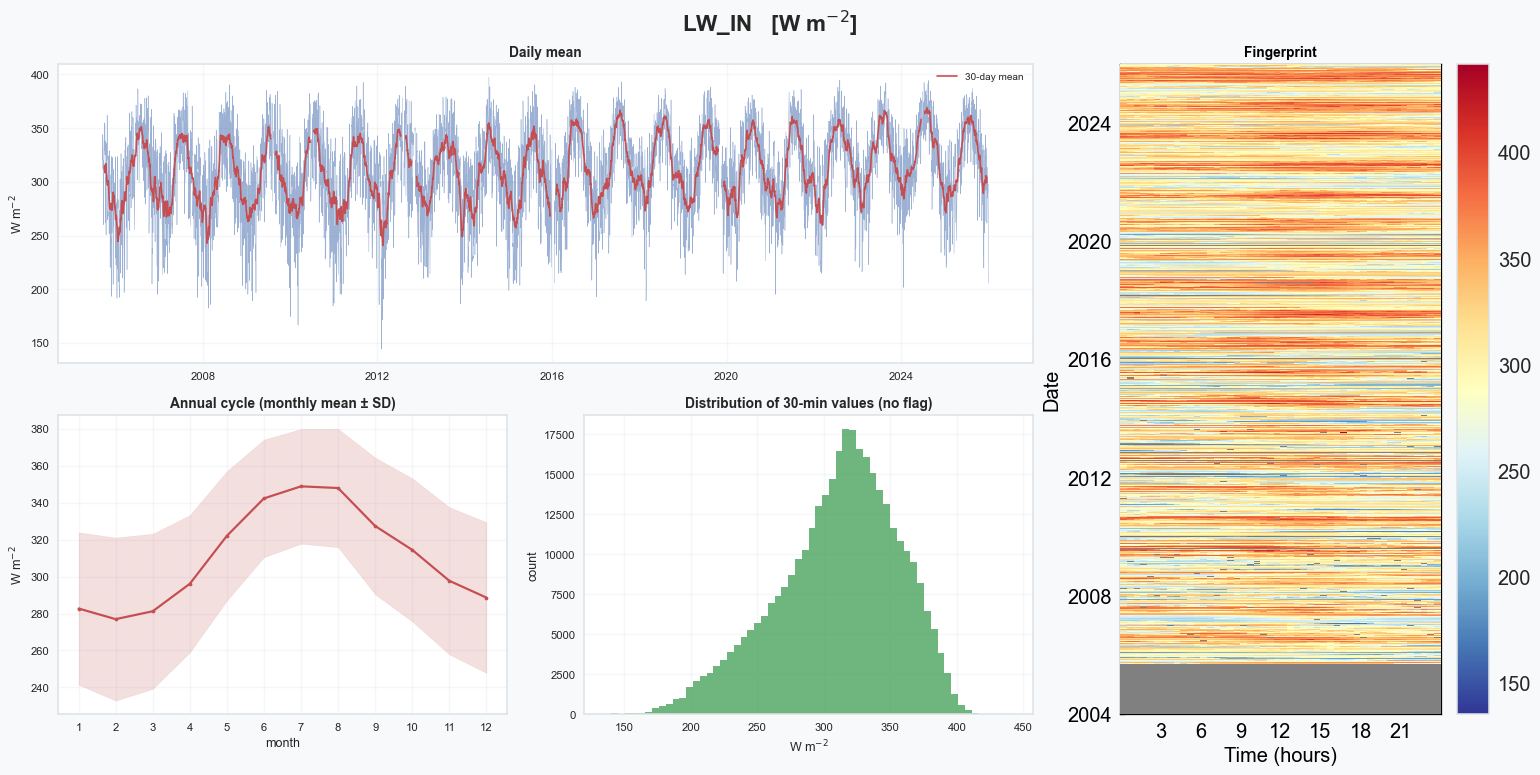

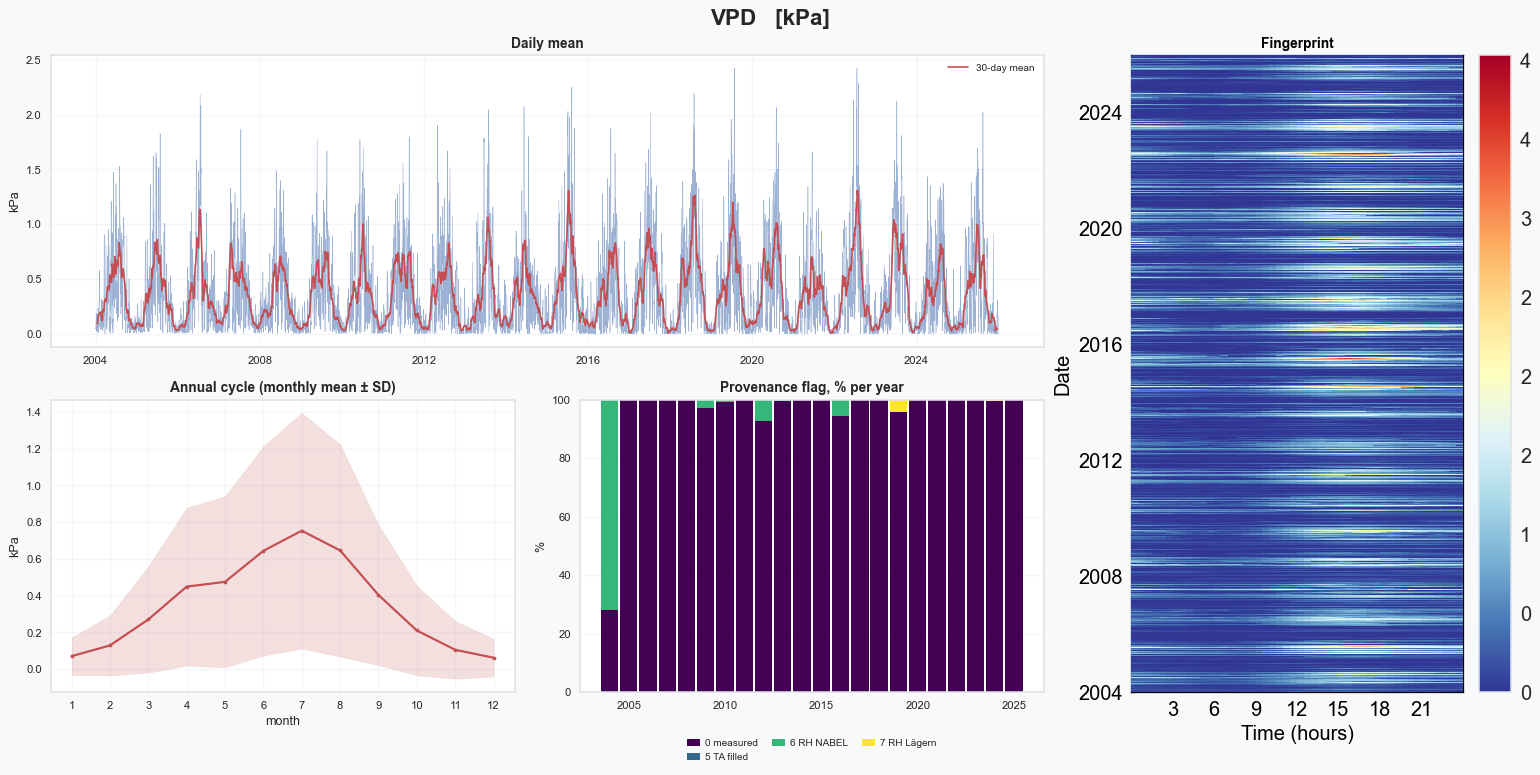

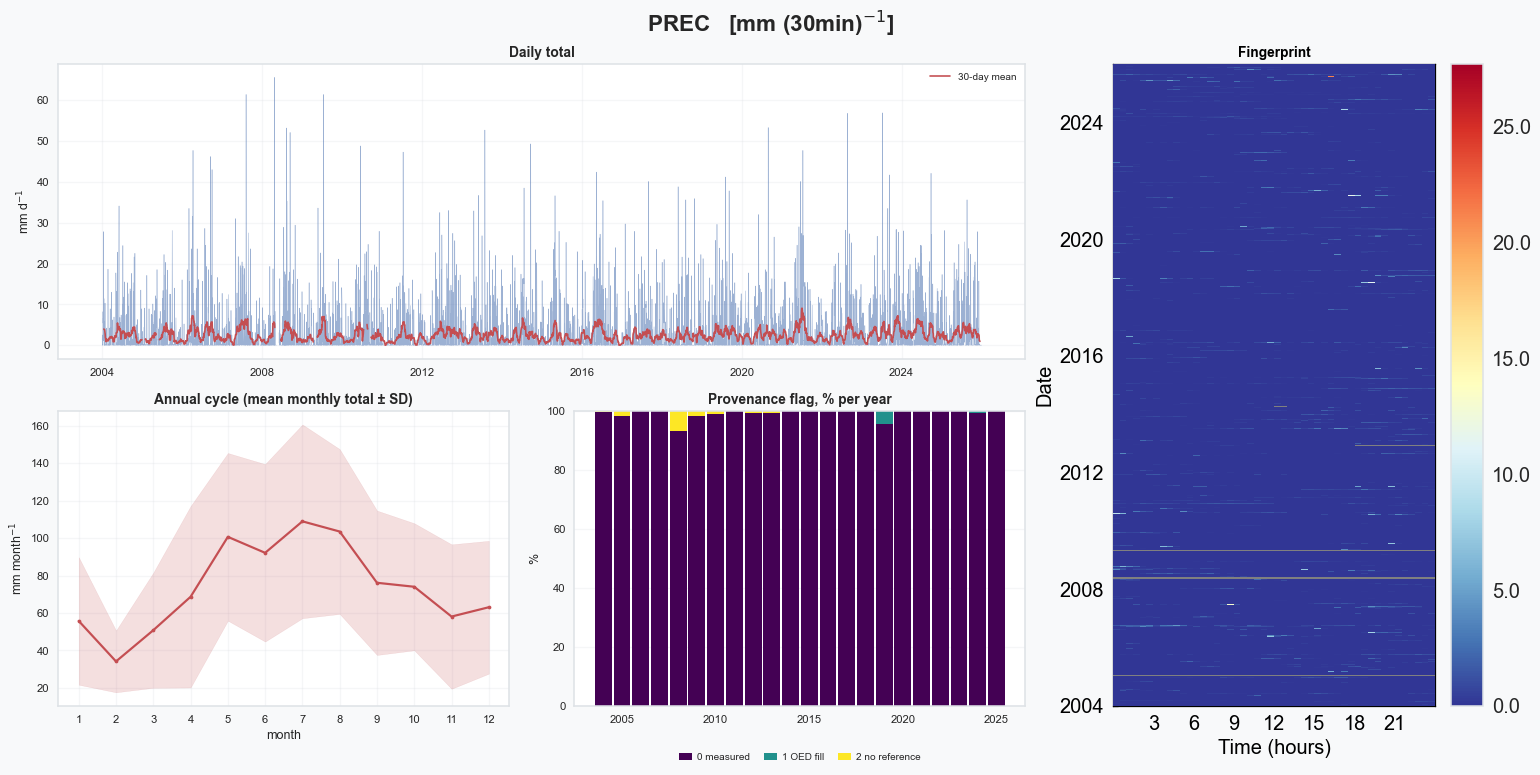

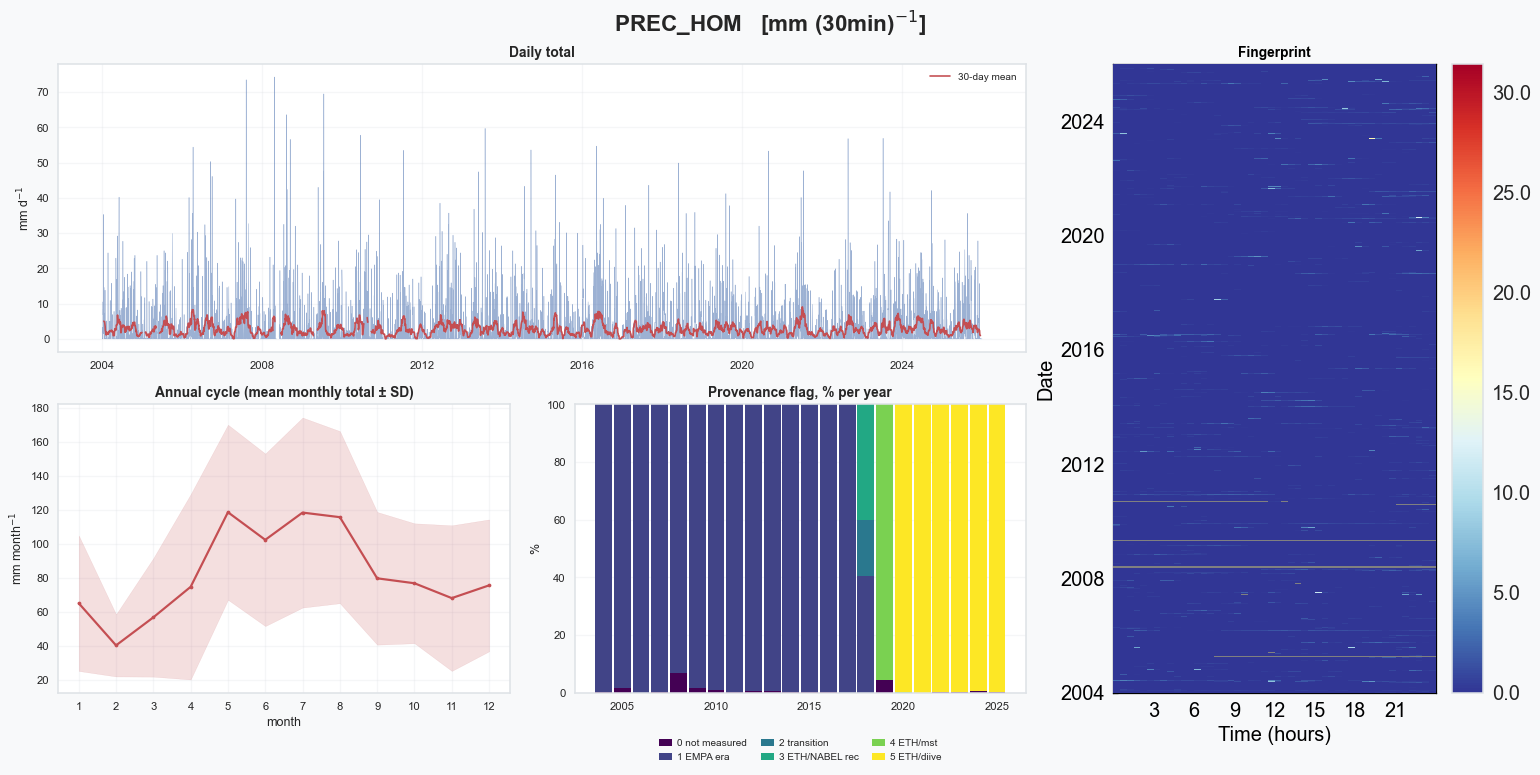

In [8]:
for _stem, _vcol, _fcol, _short, _units, _agg in PRODUCTS:
    _flag = merged[_fcol] if _fcol else None
    fig = overview_figure(merged[_vcol], _flag, _short, _units,
                          FLAG_LABELS.get(_short, {}), agg=_agg)
    plt.show()

***

In [9]:
print(f"Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Finished: 2026-07-21 16:57:44
